# Contenuti
- [Scikit-image](#Scikit-image)
- [Import delle librerie](#Import-delle-librerie)
- [Caricamento del dataset](#Caricamento-del-dataset)
- [Classificazione a partire dai pixel](#Classificazione-a-partire-dai-pixel)
- [Estrazione delle feature (HOG)](#Estrazione-delle-feature-%28HOG%29)
- [Addestramento del classificatore](#Addestramento-del-classificatore)
- [Esercizio](#Esercizio)
- [Test](#Test)

# Esercitazione 4
Nell'esercitazione odierna si applicheranno diversi algoritmi classici di Machine Learning (*SVM*, *k-NN*, *Random Forest* e *AdaBoost*) a un problema di classificazione binario di **immagini RGB** raffiguranti cani e gatti.

Al fine di manipolare e adattare le immagini verranno utilizzate alcune funzionalità messe a disposizione dalla libreria **Scikit-image**. 

Nel corso dell'esercitazione si dovranno individuare l'algoritmo e le combinazioni di iperparametri che permettono di massimizzare l’accuratezza sul dataset fornito. A tal fine si faccia riferimento alle tecniche viste nell'ambito dell'esercitazione precedente.

Infine si dovrà verificare l'accuratezza della soluzione trovata sul dataset di test per provarne l’effettiva capacità di generalizzazione.

# Scikit-image
Scikit-image è una libreria Python che mette a disposizione numerose classi e funzionalità per l'elaborazione di immagini.

Condivide con Scikit-learn la facilità d'uso, l'ampia possibilità di parametrizzare le operazioni messe a disposizione e l'integrazione con la libreria Numpy. Allo stesso modo lo stile della documentazione e della API è estremamente simile a quello di Scikit-learn.

Per una lista completa delle funzionalità si rimanda alla [documentazione ufficiale](http://scikit-image.org/docs/stable/).

# Import delle librerie
Per prima cosa è necessario eseguire l'import delle librerie utilizzate durante l'esecitazione. Il modulo necessario per utilizzare la libreria Scikit-image si chiama **skimage**.

In [233]:
%matplotlib inline
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Memory
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler
from skimage import feature, color, transform
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split, ParameterGrid, StratifiedShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn import *
import random

import ml_utilities
import ml_visualization

import os
import matplotlib.image as img

In [92]:
import sys
!{sys.executable} -m pip install xgboost

In [93]:
from numpy import loadtxt
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [2]:
np.random.seed(42)
random.seed(42)

# Caricamento del dataset
Il dataset consiste in un insieme di immagini RGB di cani e gatti. Prima di caricarlo è necessario definire:
- il percorso in cui sono memorizzate le immagini dei dataset (*db_path*);
- il percorso di una cartella di lavoro (*exp_path*) dove, durante l'elaborazione, saranno memorizzati file intermedi;
- il path del file contenente la lista delle immagini e relative etichette di classe da utilizzare come training set (*train_filelist*).

In [3]:
import zipfile

zip_files = ['test1', 'train']

for zip_file in zip_files:
    with zipfile.ZipFile("DBs/dogs-vs-cats/{}.zip".format(zip_file),"r") as z:
        z.extractall(".")
        print("{} unzipped".format(zip_file))

test1 unzipped
train unzipped


In [6]:
TRAIN_DIR_PATH = 'DBs/dogs-vs-cats/train'
file_names = os.listdir(TRAIN_DIR_PATH)
print('There are {} number of images in directory.'.format(len(file_names)))

There are 25000 number of images in directory.


In [16]:
def to_dataframe(file_names):
    files, labels = list(), list()
    for file in file_names:
        files.append('train/' + file)
        label = 0 if file[:3] == 'cat' else 1
        labels.append(label)
    df = pd.DataFrame({'filename':files, 'label':labels})
    return df

df = to_dataframe(file_names)

In [17]:
result_path = 'DBs/dogs-vs-cats/train2.txt'
with open(result_path, "w") as f:
    f.write(df.to_string(header=False, index=False))

In [9]:
df.head()

,filename,label
0,cat.0.jpg,0
1,cat.1.jpg,0
2,cat.10.jpg,0
3,cat.100.jpg,0
4,cat.1000.jpg,0


In [11]:
cat = [file for file in file_names if file[:3]=='cat'] #cat images
dog = [file for file in file_names if file[:3]=='dog'] #dog images

cat.0.jpg
cat.1.jpg
cat.10.jpg
cat.100.jpg
cat.1000.jpg


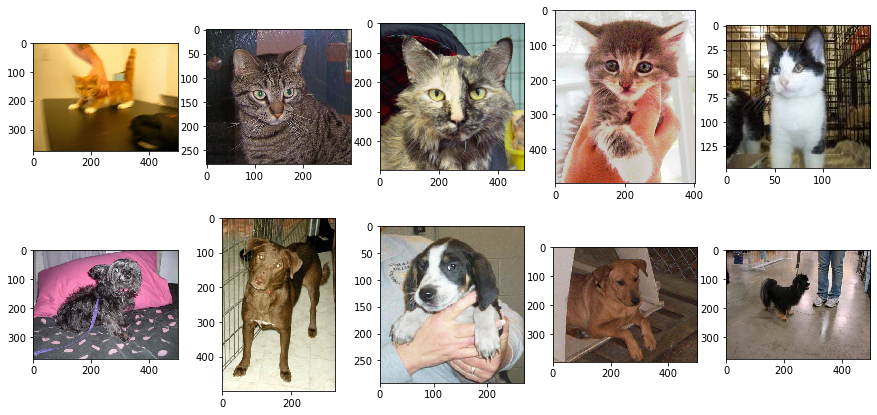

In [12]:
plt.figure(figsize=(15,7))
for i, c in enumerate(range(5), start=1):
    im = img.imread(TRAIN_DIR_PATH + '/' + cat[c])
    print(cat[c])
    plt.subplot(2,5,i)
    plt.imshow(im)
    
for i, c in enumerate(range(5), start=6):
    im = img.imread(TRAIN_DIR_PATH + '/' + dog[c])
    plt.subplot(2,5,i)
    plt.imshow(im)

In [13]:
print('Number of cat images =',len(cat))
print('Number of dog images =',len(dog))

Number of cat images = 12500
Number of dog images = 12500


In [65]:
db_path = 'DBs/CaniGatti_ML18'
exp_path = 'Experiments'
train_filelist = 'BinaryTrainingSet.txt' 

# Predisposizione di un'area di caching su disco che velocizza la riesecuzione di chiamate di funzioni con gli stessi parametri
memory = Memory(exp_path, verbose=0)  

# Caricamento delle immagini
print('Caricamento in corso ...')
start = time.time()
train_raw_x, train_y = ml_utilities.load_labeled_dataset(train_filelist, db_path, cache=memory)

print('Caricate %d immagini in %.2f s.' % (len(train_raw_x), time.time() - start))
print('Gatti:', np.count_nonzero(train_y == 0))
print('Cani:', np.count_nonzero(train_y == 1))

Caricamento in corso ...
Caricate 900 immagini in 15.19 s.
Gatti: 509
Cani: 391


In [40]:
db_path2 = 'DBs/dogs-vs-cats'
train_filelist2 = 'train2.txt'

memory = Memory(exp_path, verbose=0)  

# Caricamento delle immagini
print('Caricamento in corso ...')
start = time.time()
train_raw2_x, train2_y = ml_utilities.load_labeled_dataset(train_filelist2, db_path2, cache=memory)

print('Caricate %d immagini in %.2f s.' % (len(train_raw2_x), time.time() - start))
print('Gatti:', np.count_nonzero(train2_y == 0))
print('Cani:', np.count_nonzero(train2_y == 1))

Caricamento in corso ...
Caricate 25000 immagini in 661.09 s.
Gatti: 12500
Cani: 12500


In [66]:
print(len(train_raw2_x))
print(len(train2_y))

print(len(train_raw_x))
print(len(train_y))

25000
25000
900
900


In [ ]:
train_y = train_y.tolist()
train2_y = train2_y.tolist()

In [85]:
print(type(train_raw_x))
print(type(train_raw2_x))

print(type(train_y))
print(type(train2_y))

<class 'numpy.ndarray'>
<class 'list'>
<class 'list'>
<class 'numpy.ndarray'>


In [68]:
train_raw_x.extend(train_raw2_x)

In [69]:
len(train_raw_x)

25900

In [86]:
train_y.extend(train2_y)

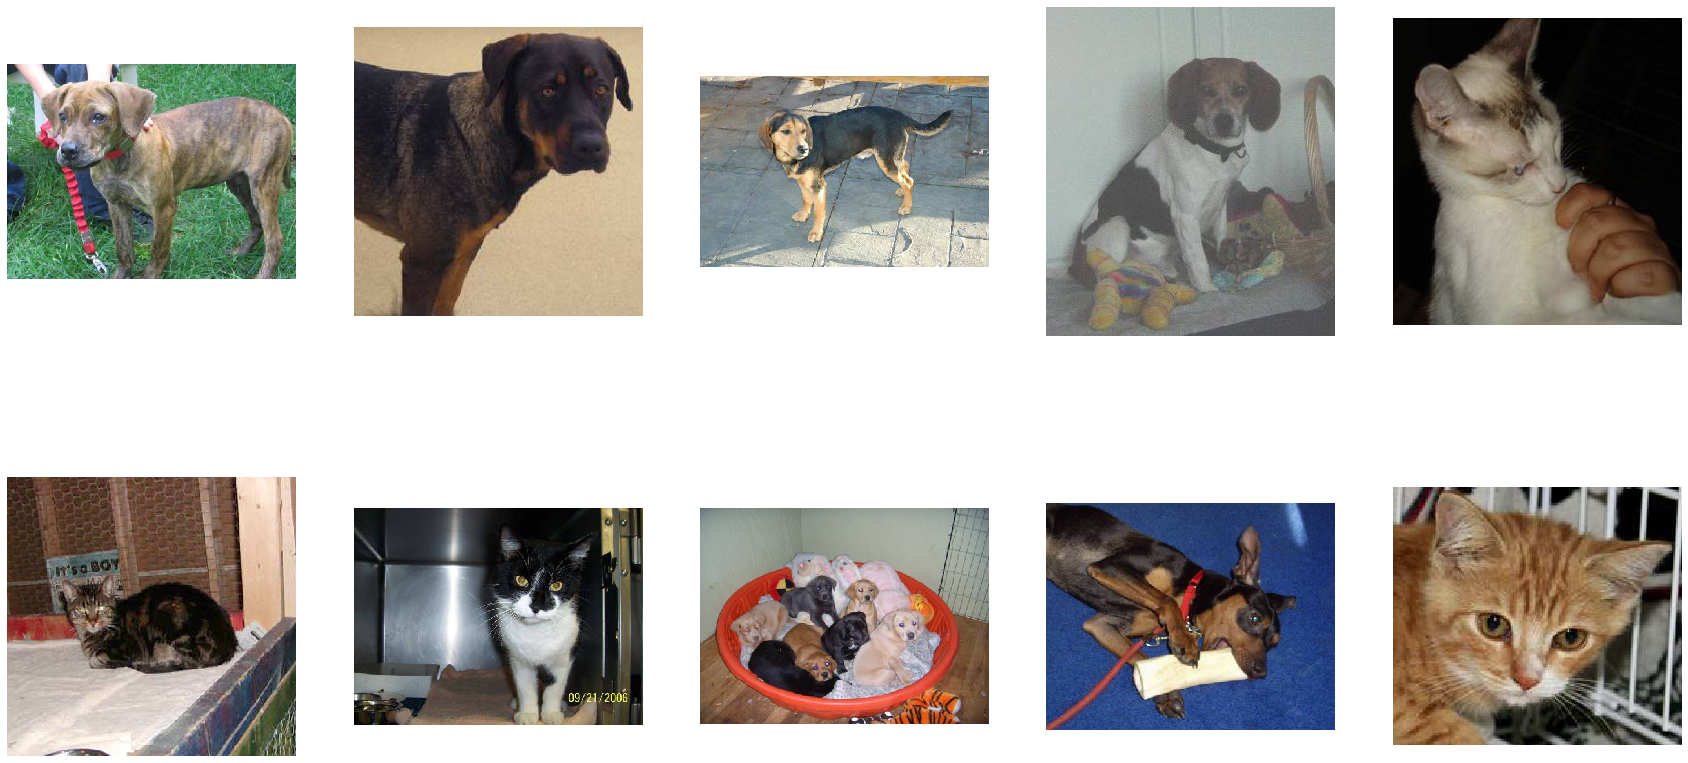

In [70]:
# Shuffle del training set
ml_utilities.shuffle_in_unison([train_raw_x, train_y], seed=42)

# Visualizzazione immagini
_, axs = plt.subplots(2, 5,figsize=(30, 15))
for i in range(5):
    axs[0,i].imshow(train_raw_x[i]),axs[0,i].axis('off')
    axs[1,i].imshow(train_raw_x[5+i]),axs[1,i].axis('off')
plt.show()

#ci sono più gatti che cani e quindi il dataset non è perfettamente bilanciato

Se le dimensioni delle immagini in input sono eterogenee, prima di poterle utilizzare è necessario portarle tutte a delle dimensioni prefissate ($\textit{image_side} \times \textit{image_side}$) come mostrato nella cella seguente.

Resizing in corso ...
Resizing completato in 2292.92 s.


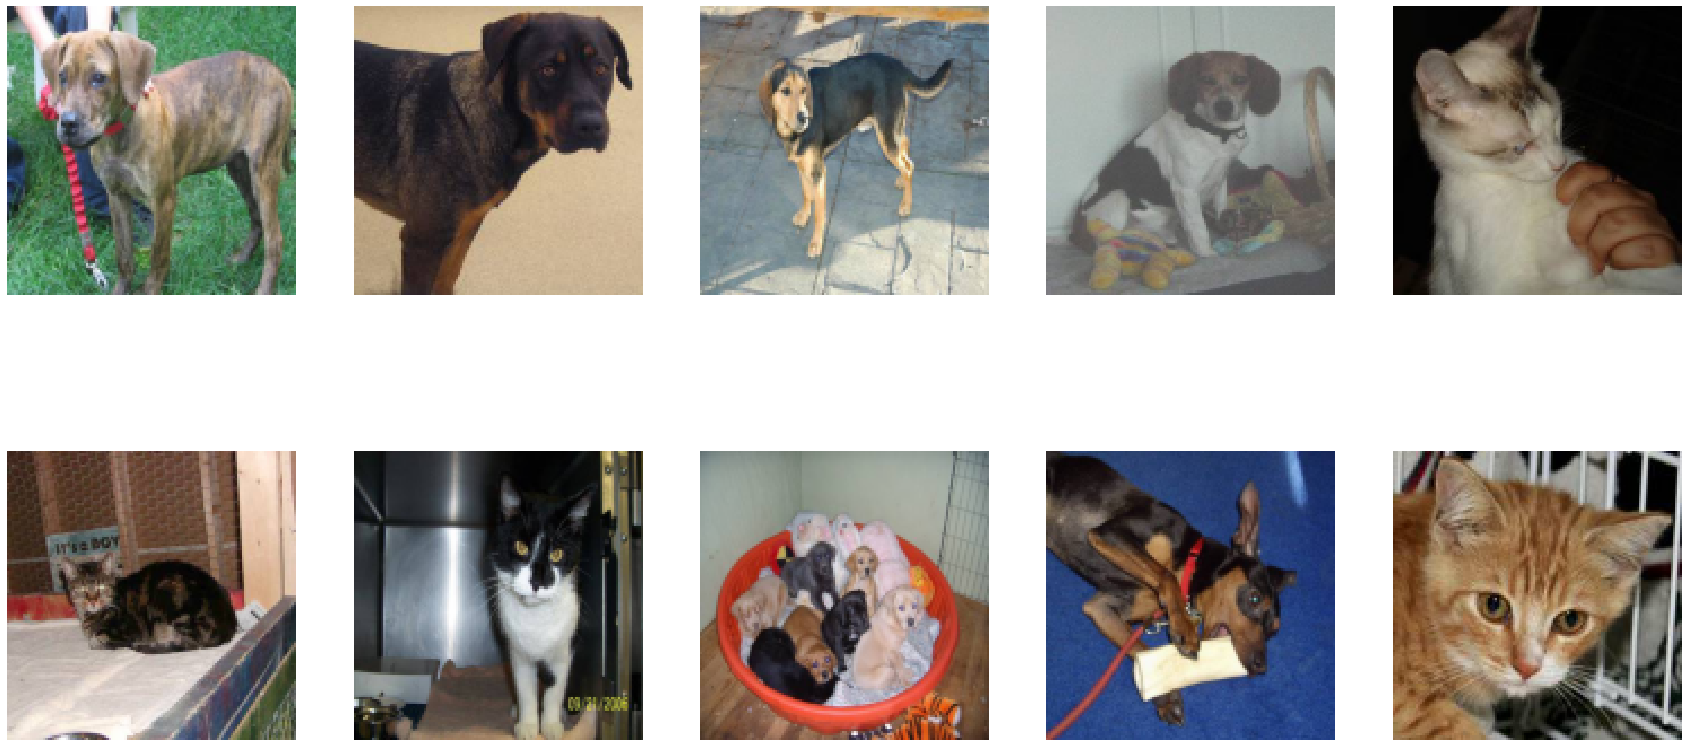

In [71]:
resizing = True
image_side = 128

if resizing:
    # Resize
    print('Resizing in corso ...')
    start = time.time()
    train_raw_x = ml_utilities.resize_images(train_raw_x, image_side, image_side, cache=memory)
    #per ridurre la dimensionalità (quando utilizzeremo diversi classificatori)
    
    print('Resizing completato in %.2f s.' % (time.time() - start))
    
    # Visualizzazione immagini
    _, axs = plt.subplots(2, 5,figsize=(30, 15))
    for i in range(5):
        axs[0,i].imshow(train_raw_x[i]),axs[0,i].axis('off')
        axs[1,i].imshow(train_raw_x[5+i]),axs[1,i].axis('off')
    plt.show()

# Classificazione a partire dai pixel

Le immagini ottenute (anche a seguito di *resizing*) sono molto grandi per poter essere utilizzate direttamente come input di un classificatore tradizionale. Infatti un'immagine $\textit{128} \times \textit{128} \times \textit{3}$ corrisponde a un pattern 49152-dimensionale.

Utilizzando un *SVM* il tempo di training è di circa 2 minuti (utilizzando la classe **LinearSVC** ottimizzata per *kernel* lineare) per ottenere un'accuratezza intorno al 57% (di poco superiore alla scelta casuale!).

Nel settore della visione artificiale per l'addestramento di classificatori (qualora non si utilizzino tecniche di deep learning quali le reti CNN) è prassi consolidata estrarre dalle immagini feature **robuste** e **compatte**.

Perchè l'intensità dei pixel non è una feature robusta?
<img src="pixel_dist.png" alt="" style="width: 600px;"/>

Variazioni di posa, e illuminazione possono rendere campioni della stessa classe molto diversi tra loro in termini di intensità di pixel corrispondenti.

Purtroppo non esiste un tipo di feature idoneo per tutti i problemi ma è necessario padroneggiare il dominio applicativo per scegliere/progettare in modo ottimale le feature da utilizzare (si parla di *feature engineering* o *handcrafted features*).

In [5]:
# ho ottenuto una distanza minore, quindi si potrebbe dire che sono più simili quelle sotto
# questo perchè le due immagini sopra sono mal allineate
# e quado fa la differenza tra una zona chiara e una zona scura viene fuori una distaza maggiore

# Estrazione delle feature (HOG)
In questa esercitazione utilizzeremo le feature note come *Histogram of Oriented Gradients* ([HOG](https://en.wikipedia.org/wiki/Histogram_of_oriented_gradients)), originariamente introdotte per *pedestrian detection*, ma applicabili anche ad altri domini.

Un'implementazione è disponibile nella libreria  [Scikit-image](http://scikit-image.org/docs/dev/api/skimage.feature.html#skimage.feature.hog).

Per estrarre le orientazioni, il metodo HOG non ha evidenti vantaggi dall'uso del colore. Pertanto prima dell'estrazione le immagini possono essere convertite da RGB (3 byte per pixel) in scala di grigi (1 byte per pixel).

L'immagine viene suddivida in blocchi. Per ognuno di essi HOG estrae le orientazioni del gradiente e le riassume attraverso un istogramma. 

La funzione **hog(...)** restituisce un **ndarray** monodimensionale contenente le feature estratte. Con il paramentro opzionale (*visualise*) è possibile ottenerne una visualizzazione grafica utile per comprendere meglio la natura delle feature estratte. La cella seguente visualizza una rappresentazione HOG relativa a un'immagine di esempio.

https://www.analyticsvidhya.com/blog/2019/09/feature-engineering-images-introduction-hog-feature-descriptor/

Numero feature: 2304


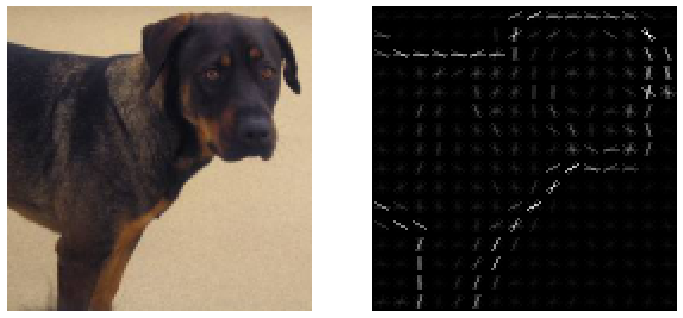

In [87]:
image_index = 1  # Modificare con un indice a piacere

# Conversione in grayscale
grayscale_image = color.rgb2gray(train_raw_x[image_index]) #a partire dall'immagine rgb

# Estrazione delle feature
hog_features, hog_image = feature.hog(grayscale_image,
                                      orientations=9, pixels_per_cell=(8, 8),
                                      cells_per_block=(1, 1),  block_norm='L2-Hys',
                                      visualize=True)  
# utilizziamo hog perchè sono più robusti dei pixel
# otteniamo in ogni cella della matrice c'è un istogramma e il gradiente dei vari edge

# quanti blocchettini creare nella matrice = sono 16x16
# 16x16x9 = 2304

print('Numero feature:', len(hog_features))

# Visualizzazione HOG
_, axs = plt.subplots(1, 2,figsize=(12, 6))
axs[0].imshow(train_raw_x[image_index]),axs[0].axis('off')
axs[1].imshow(hog_image),axs[1].axis('off')
plt.show()

La procedura appena descritta deve essere applicata a tutte le immagini. Per fare ciò è possibile utilizzare la funzione **extract_hog(...)** del modulo *ml_utilities* come mostrato di seguito:

In [73]:
print('Estrazione delle feature HOG in corso ...')
start = time.time()
train_feature_x = ml_utilities.extract_hog(train_raw_x, 
                                           convert_to_gray=True, orientations=9,
                                           pixels_per_cell=(8, 8), cells_per_block=(1, 1),
                                           cache=memory)
print('Estrazione completata in %.2f s.' % (time.time() - start))
#nelle colonne si hanno 2304 feature (generate prima)

Estrazione delle feature HOG in corso ...
Estrazione completata in 777.48 s.


In [122]:
print(len(train_raw_x[0]))
print(len(train_feature_x[0]))

128
2304


# Addestramento del classificatore
Completata la fase di **estrazione** delle feature, è possibile utilizzarle per addestrare un classificatore.

Il dataset *train_feature_x* e la lista delle etichette di classe *train_y* sono nel formato richiesto dall'API di Scikit-learn.

In Scikit-learn oltre a [*k-NN*](http://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) e [*SVM*](http://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html) (visti nell'esercitazione precedente) sono presenti anche i classificatori [*Random Forest*](http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) e [*AdaBoost*](http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html). 

Di seguito vengono riportate le istruzioni necessarie per creare e addestrare un classificatore:

In [246]:
model_params = {
    'SVC': {
        'model': SVC(),
        'params' : {
            'C': [2**i for i in range(-5,16)],
            'kernel': ['rbf'],
            'gamma': [2**i for i in range(-15,4)]
        }
    },
    'RandomForestClassifier': {
        'model': RandomForestClassifier(),
        'params' : {
            'n_estimators' : [],
            'max_depth' : [],
            'criterion' : ["gini", "entropy", "log_loss"]
        }
    },
    'AdaBoostClassifier' : {
        'model': AdaBoostClassifier(),
        'params': {
            'n_estimators' : [],
            'learning_rate' : []
        }
    },
    'XGBClassifier' : {
        'model': XGBClassifier(),
        'params' : {}
    },
    'LogisticRegression' : {
        'model': LogisticRegression(),
        'params': {
            'penalty' : ["l1", "l2", "elasticnet", "none"],
            'C' : [2**i for i in range(-5,16)],
            'fit_intercept' : [],
            'solver' : ["newton-cg", "lbfgs", "liblinear", "sag", "saga"]
        }
    }
}
# KNeighborsClassifier()
scores=[]

In [247]:
params = {
    'C': [2**i for i in range(-5,16)],
    'kernel': ['rbf'],
    'gamma': [2**i for i in range(-15,4)],
}
clf = SVC()
scores = []

In [ ]:
for data_test_size in [0.3]: #[0.3, 0.4, 0.5]
    for folds in [5, 7, 9, 11]:
        cross_val = StratifiedShuffleSplit(n_splits=folds, test_size=data_test_size)
        grid =  GridSearchCV(clf,
                             param_grid=params,
                             cv=cross_val)

        start = time.time()
        print('Addestramento in corso ...')
        grid.fit(train_feature_x, train_y)
        print('Addestramento completato in %.2f s.' % (time.time() - start))
        scores.append({
            'data_test_size': data_test_size,
            'folds': folds,
            'best_score': grid.best_score_,
            'mean_test_score': grid.cv_results_['mean_test_score'],
            'best_params': grid.best_params_,
        })
        print(f"fit completed")
    dataFrame = pd.DataFrame(scores,columns=['data_test_size','folds','best_score','mean_test_score','best_params'])
    print(f"data_test_size= {data_test_size} and folds = {folds}")
    print(f"fit completed")

Addestramento in corso ...


In [88]:
start = time.time()
#clf = KNeighborsClassifier()
clf = SVC()
#clf = RandomForestClassifier(random_state=1234)
#clf = AdaBoostClassifier(random_state=1234)

print('Addestramento in corso ...')
clf.fit(train_feature_x, train_y)
print('Addestramento completato in %.2f s.' % (time.time() - start))

Addestramento in corso ...
Addestramento completato in 1854.21 s.


È possibile stimare l'accuratezza di un classificatore utilizzando il metodo **.predict(...)**. Il metodo restituisce le predizioni del classificatore su un insieme di pattern che, confrontate con le etichette reali, permettono di calcolarne l'accuratezza. Ad esempio:

Valutazione sul training set in corso ...
Valutazione sul training set completata in 3738.93 s.
Accuratezza: 0.9311583011583011


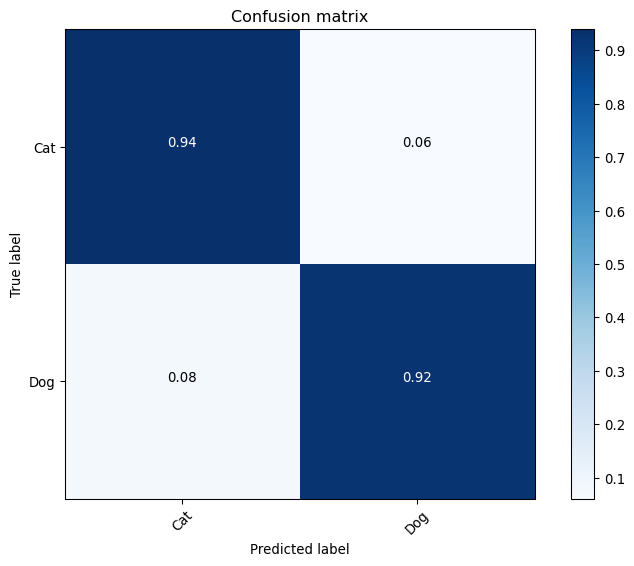

In [99]:
print('Valutazione sul training set in corso ...')
start = time.time()
train_predictions = clf.predict(train_feature_x)
print('Valutazione sul training set completata in %.2f s.' % (time.time() - start))

# Calcolo accuratezza
train_accuracy = (train_predictions == train_y).sum()/len(train_y)
# oppure si può utilizzare la funzione score di sklearn, è uguale 
print('Accuratezza:', train_accuracy)

# Visualizzazione Confusion Matrix
ml_visualization.plot_confusion_matrix(train_y, train_predictions, ['Cat', 'Dog'])
                                    # label true, label predicted
# indovina solo il 19% di cani
# gli altri 81% sbaglia e li classifica come gatti (perchè sono di più nel data set, è sbilanciato)

# Esercizio
L'obiettivo è massimizzare l'accuratezza di classificazione, valutando (con *Cross-Validation*):
- l'impiego di diversi classificatori, come [*k-NN*](http://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html), [*SVM*](http://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html), [*Random Forest*](http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html), [*AdaBoost*](http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html) o altri. È possibile utilizzare qualsiasi tipologia di classificatore tranne quelli basati su reti neurali.
- l'ottimizzazione dei relativi iperparametri;
- l'ottimizzazione dei parametri utilizzati per estrarre le feature HOG;
- la combinazione di più classificatori.

Si consiglia di procedere iterativamente a partire da un insieme limitato di combinazioni per poi raffinare la ricerca: infatti, i tempi richiesti per l'esecuzione di [**cross_val_score(...)**](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html) e [**GridSearchCV(...)**](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) possono diventare proibitivi per un elevato numero di combinazioni di iperparametri e *fold*.

**NOTA BENE:**
 - Il classificatore dovrà essere **addestrato e testato sulle feature HOG** estratte dai pattern del dataset (quindi non direttamente sulle immagini originali);
 - Non è (ovviamente) possibile utilizzare i pattern del test set per l'addestramento del classificatore;
 - **Non è consentito aggiungere immagini esterne** al training set così come non è possibile utilizzare immagini derivate (*augmentation*).

In [18]:
# Consigli:

# non usare KNN
# si può usare anche XGBoost
# è consentito fare augmentation: aggiungere altre immagini al data set, usare immagini esterne

# usare stratify per ottenere più o meno la stessa proporzione di cani e gatti
# cross_val_score o GridSearchCV non c'è bisogno (lo fanno in "automatico")

# cambiare iperparametri delle hog (per creare le feature)
# cambiare iperparametri dei classificatori

In [19]:
# Esercizio 1: ottimizzazione iperparametri
# ...

# Test
Si addestri il classificatore desiderato utilizzando gli iperparametri trovati nell'esercizio precedente. Il codice contenuto nella cella seguente userà tale classificatore per predire la classe dei pattern del dataset di test. Le classi predette verranno salvate su un file di testo che dovrà essere caricato sul sito della competizione per misurarne l'accuratezza.
Le procedure utilizzate per caricare i dataset, per estrarne le feature e per addestrare il classificatore desiderato dovranno essere riportate nella cella seguente. Ai fini della competizione si ricorda che nel file .zip dovrà essere inclusa anche una cartella "Codice" contenente una copia di questo notebook e degli script Python utilizzati.

In [186]:
# Caricamento dei pattern di test
test_filelist = 'Unlabeled_BinaryTestSet.txt'
result_path = 'Es4Predictions.txt'

memory = Memory(exp_path, verbose=0) 

test_raw_x = ml_utilities.load_unlabeled_dataset(test_filelist, db_path, cache=memory)

In [187]:
# Resize
print('Resizing in corso ...')
start = time.time()
test_raw_x = ml_utilities.resize_images(test_raw_x, image_side, image_side, cache=memory)
print('Resizing completato in %.2f s.' % (time.time() - start))

Resizing in corso ...
Resizing completato in 3.63 s.


In [188]:
# Preprocessing ed estrazione HOG (test)
print('Estrazione delle feature HOG in corso ...')
start = time.time()
test_feature_x = ml_utilities.extract_hog(test_raw_x, 
                                           convert_to_gray=True, orientations=9,
                                           pixels_per_cell=(8, 8), cells_per_block=(1, 1),
                                           cache=memory)
# stessi parametri utilizzati per il training set
print('Estrazione completata in %.2f s.' % (time.time() - start))

Estrazione delle feature HOG in corso ...
Estrazione completata in 3.02 s.


In [189]:
print(len(test_raw_x[0]))
print(len(test_feature_x[0])) #16*16*9

128
2304


In [190]:
print('Predizioni test set in corso ...')
start = time.time()
predictions = clf.predict(test_feature_x)
print('Predizioni test set completata in %.2f s.' % (time.time() - start))

Predizioni test set in corso ...
Predizioni test set completata in 19.08 s.


In [ ]:
# Salvataggio delle predictions
with open(result_path, "w") as f:
    for prediction in predictions:
        f.write(str(int(prediction)) + '\n')
print('Ok')

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------

In [191]:
test_path = 'DBs/CaniGatti_ML18/Unlabeled_BinaryTestSet.txt'

test_df = pd.read_table(test_path, delimiter="/", names=["path1","path2","filename"])

In [196]:
preds = list()
while i < len(test_df):
    pred = 0 if test_df["filename"][i][0:3]=='cat' else 1
    preds.append(pred)
    i = i + 1

In [212]:
test_labels = list()
for file in test_df["filename"]:
    label = 0 if file[0:3]=='cat' else 1
    test_labels.append(label)

In [213]:
test_df2 = pd.DataFrame({ 'filename' : test_df["filename"], 'label' : test_labels })
test_df2

,filename,label
0,cat_mia_A623088E_00104615.jpg,0
1,cat_mia_A623088E_079EDE98.jpg,0
2,cat_mia_A623088E_18EBECEE.jpg,0
3,cat_mia_A623088E_27212EA3.jpg,0
4,cat_mia_A623088E_34BB9C9E.jpg,0
...,...,...
145,cat_billy_4D0E598C_7F710A64.jpg,0
146,cat_billy_4D0E598C_85F1529D.jpg,0
147,cat_billy_4D0E598C_98F0EC50.jpg,0
148,cat_billy_4D0E598C_9C3653A3.jpg,0


In [232]:
print("Cat: " + str(test_df2[test_df2["label"] == 0].shape[0]))
print("Dog: " + str(test_df2[test_df2["label"] == 1].shape[0]))

Cat: 85
Dog: 65


Accuratezza: 0.9311583011583011


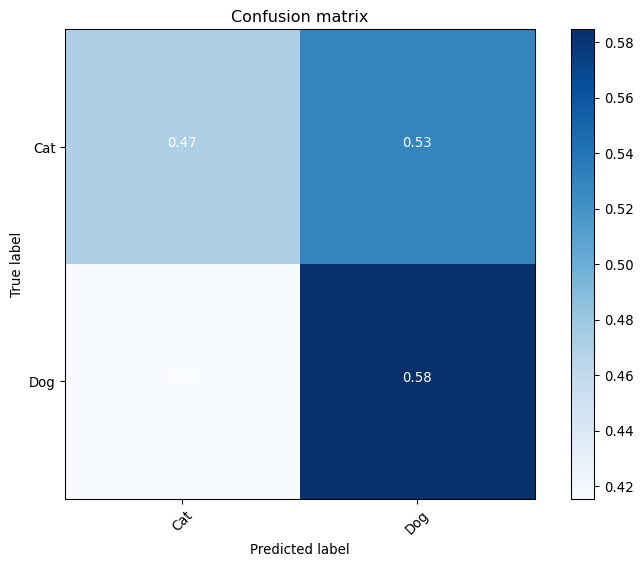

In [214]:
# Calcolo accuratezza
test_accuracy = (predictions == test_labels).sum()/len(test_labels)
print('Accuratezza:', train_accuracy)

# Visualizzazione Confusion Matrix
ml_visualization.plot_confusion_matrix(test_labels, predictions, ['Cat', 'Dog'])

In [ ]:
# Esercizio 2: valutazione su test set

# Path contenente i pattern di test
image_side = 128
db_path = 'DBs/CaniGatti_ML18'
exp_path = 'Experiments'
train_filelist = 'BinaryTrainingSet.txt' 
test_filelist = 'Unlabeled_BinaryTestSet.txt'
result_path = 'Es4Predictions.txt'
memory = Memory(exp_path, verbose=0) 

# Caricamento dei pattern di training
# ...

# Preprocessing ed estrazione HOG (training)
# ...

# Creazione del classificatore
# clf = ...
# ...

# Addestramento del classificatore
# ...

# Caricamento dei pattern di test
test_raw_x = ml_utilities.load_unlabeled_dataset(test_filelist, db_path, cache=memory)

# Preprocessing ed estrazione HOG (test)
# ...

# Salvataggio delle predictions
predictions = clf.predict(test_feature_x)

with open(result_path, "w") as f:
    for prediction in predictions:
        f.write(str(int(prediction)) + '\n')
print('Ok')